In [1]:
from func import classify_timecell
import numpy as np
from matplotlib import pyplot as plt

In [2]:
def plt_hs(hs, min_fr=0.1, masks=None, fig=None, ax=None):

    time_points = hs.shape[0]

    # Select neurons with mean firing rate > 0.1
    mean_fr = hs.mean(axis=0)
    # Get the index where mean_fr > min_fr
    mask = mean_fr > min_fr
    neuron_indices = np.where(mask)[0]
    select_hs = hs[:, neuron_indices]
    del hs

    # Normalize the hs along time points (Sure to be correct!)
    # norm_hs = select_hs / np.linalg.norm(select_hs, axis=0, keepdims=True)
    # 0-1 Normalise method 2
    norm_hs = np.zeros_like(select_hs)
    for n in range(select_hs.shape[1]):
        norm_hs[:, n] = (select_hs[:, n]-np.min(select_hs[:, n]))/(np.max(select_hs[:, n])-np.min(select_hs[:, n]))
    del select_hs
    
    # Sort neurons from maximum firing time
    max_time = np.argmax(norm_hs, axis=0)
    sorted_neuron_indices = np.argsort(max_time)
    norm_hs = norm_hs[:, sorted_neuron_indices]
    num_neurons = norm_hs.shape[1]
    
    # Plot the normalized hs
    ax.imshow(norm_hs.T, aspect='auto', cmap='jet',  
              extent=[0, time_points/10, 0, num_neurons]
              )
    # ax.set_xlabel('Time (s)')
    ax.set_ylabel('Neurons')
    ax.set_xticks(np.linspace(0, norm_hs.shape[0]/10, 6))

    if masks is not None:
        for m in masks:
            ax.axvline(x=m[0], color='white', linestyle='--', linewidth=1)
            ax.axvline(x=m[1], color='white', linestyle='-', linewidth=1)
            # Plot a semi-transparent rectangle to cover the masked region
            ax.add_patch(plt.Rectangle((m[0], 0), m[1]-m[0], norm_hs.shape[1], 
                                       color='white', alpha=0.3))
    
    # Plot the colorbar
    cbar = fig.colorbar(ax.images[0], ax=ax)
    cbar.set_label('Normalized firing rate')
    return norm_hs, fig, ax

In [3]:
load_data_type = '2TS_trial'
num_neuron = 512
data = np.load(f'../../data/{load_data_type}.npy', allow_pickle=True).item()
hs = data[f'hidden_states_{num_neuron}']
print(hs.shape)  # (n_trials, n_neurons, n_time_bins)

(50, 200, 512)


In [4]:
avg_hs = np.mean(hs, axis=0)  # (n_neurons, n_time_bins)
print(avg_hs.shape)

(200, 512)


(200, 512)


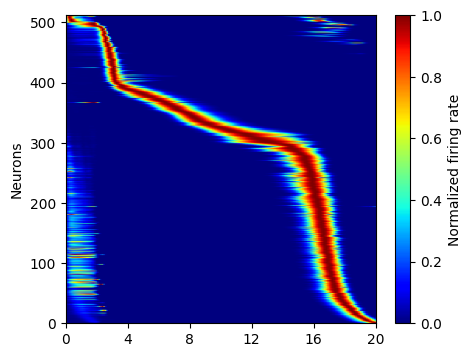

In [5]:
fig, ax = plt.subplots(1,1, figsize=(5,4))
norm_hs, fig, ax = plt_hs(avg_hs, min_fr=0, fig=fig, ax=ax)
print(norm_hs.shape)

In [6]:
norm_hsT = norm_hs.T  # (n_neurons, n_time_bins)

In [11]:
def _const_model(t, a0):
    return a0 * np.ones_like(t)

def _timecell_model(t, a0, a1, mu, sigma):
    return a0 + a1 * np.exp(-0.5 * ((t - mu)/sigma)**2)

def _timecell_model_two_peaks(t, a0, a1, mu1, sigma1, a2, mu2, sigma2):
    return (a0 + a1 * np.exp(-0.5 * ((t - mu1)/sigma1)**2) +
                 a2 * np.exp(-0.5 * ((t - mu2)/sigma2)**2))

In [8]:
# from scipy.optimize import curve_fit
# idx = 200
# popt, pcov = curve_fit(_timecell_model, np.arange(norm_hs.shape[0])/10, norm_hsT[idx],
#                         p0=[0, 1, 15, 1], bounds=([0, 0, 0, 0], [1, 5, 20, 10]))
# # Plot the fitted curve
# t_fit = np.linspace(0, norm_hs.shape[0]/10, 100)
# fit_curve = _timecell_model(t_fit, *popt)

# fig, ax = plt.subplots(1,1, figsize=(5,4))
# ax.plot(np.arange(norm_hs.shape[0])/10, norm_hsT[idx], 'b-', label='Data')
# ax.plot(t_fit, fit_curve, 'r--', label='Fitted curve')
# ax.set_xlabel('Time (s)')

In [9]:
results = classify_timecell(norm_hsT, T_total=norm_hs.shape[0]/10, threshold=0.5)

  0%|          | 0/512 [00:00<?, ?it/s]/home/shannon/vijaylab/STCell/code/time_cell_analysis/func.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt3, _ = curve_fit(_const_model, t, res, p0=p_init3, maxfev=5000)
100%|██████████| 512/512 [00:02<00:00, 196.16it/s]


{'neuron': 200, 'is_time_cell': False, 'Err1': 0.5904099364921691, 'Err2': 0.40052727507599717, 'Err3': 0.588857716670306, 'popt1': array([1.13529678e-13, 1.00000000e+00, 1.20297220e+01, 1.66622801e+00]), 'popt2': array([3.10910519e-48, 1.42174528e-01, 1.07067360e+01, 4.66767962e-01]), 'popt3': array([-0.00278587])}


Text(0.5, 0, 'Time (s)')

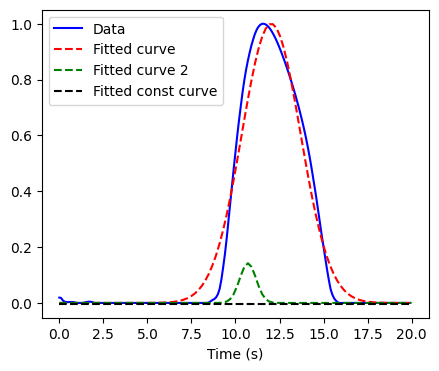

In [12]:
idx = 200
print(results[idx])

fig, ax = plt.subplots(1,1, figsize=(5,4))
t = np.arange(norm_hs.shape[0])/10
plt.plot(t, norm_hsT[idx], 'b-', label='Data')

# Plot the fitted curve
t_fit = np.linspace(0, norm_hs.shape[0]/10, 100)
fit_curve1 = _timecell_model(t_fit, *results[idx]['popt1'])
plt.plot(t_fit, fit_curve1, 'r--', label='Fitted curve')
fit_curve2 = _timecell_model(t_fit, *results[idx]['popt2'])
plt.plot(t_fit, fit_curve2, 'g--', label='Fitted curve 2')
fit_curve3 = _const_model(t_fit, *results[idx]['popt3'])
plt.plot(t_fit, fit_curve3, 'k--', label='Fitted const curve')
plt.legend()
ax.set_xlabel('Time (s)')

In [ ]:
# Get the number of time cells
time_cells = [i for i, res in enumerate(results) if res['is_time_cell'] == True]
non_time_cells = [i for i, res in enumerate(results) if res['is_time_cell'] == False]
print(len(time_cells))

239


In [ ]:
print(non_time_cells)

[1, 2, 3, 4, 6, 8, 9, 10, 12, 13, 14, 15, 16, 19, 20, 21, 22, 24, 25, 27, 28, 29, 32, 34, 35, 40, 43, 46, 48, 53, 57, 58, 62, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 84, 85, 87, 88, 89, 90, 91, 94, 95, 97, 99, 101, 105, 108, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 150, 151, 152, 153, 154, 156, 157, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 190, 196, 197, 198, 199, 200, 201, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 221, 222, 223, 224, 225, 226, 235, 238, 241, 252, 255, 258, 260, 264, 266, 270, 286, 296, 297, 298, 300, 302, 307, 309, 313, 314, 318, 322, 324, 325, 326, 327, 328, 330, 331, 333, 335, 336, 337, 338, 339, 340, 341, 342, 345, 346, 348, 349, 350, 351, 353, 355, 356, 359, 360, 363, 365, 366, 367, 368, 369, 370, 371, 372, 373, 375, 376, 377, 379, 380, 381, 382, 383, 385, 386, 387, 388, 389, 392, 393, 394, 395, 396, 397, 399, 400, 402, 403, 404,

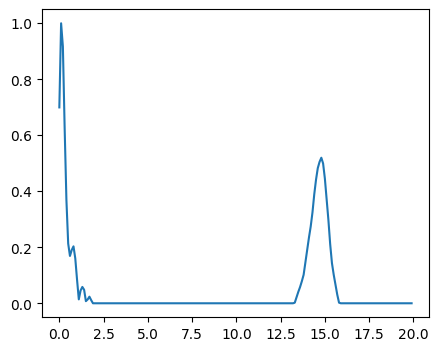

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(5,4))
t = np.arange(norm_hs.shape[0])/10
for i in non_time_cells[:1]:
    plt.plot(t, norm_hsT[i])

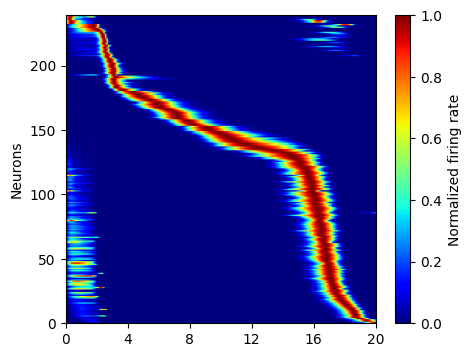

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(5,4))
_, fig, ax = plt_hs(avg_hs[:, time_cells], min_fr=0, fig=fig, ax=ax)

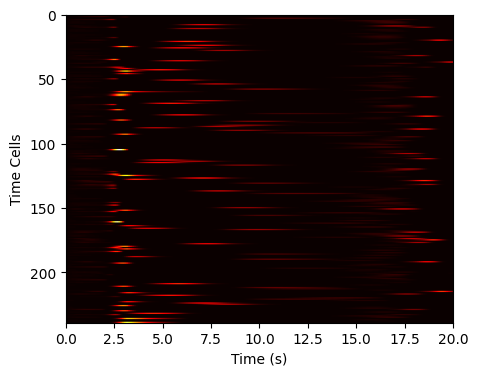

In [ ]:
# Plot example time cells
import matplotlib.pyplot as plt
time_cells_hs = avg_hs.T[time_cells]
fig, ax = plt.subplots(1,1, figsize=(5,4))
ax.imshow(time_cells_hs, aspect='auto', cmap='hot', extent=[0,20,len(time_cells),0])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Time Cells')
plt.show()